In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from Clustering import find_optimal_k, fit_kmeans, fit_hierarchical, find_optimal_eps, fit_dbscan, compare_models, _initialize_som_weights, _find_bmu, _som_learning_rate, _som_radius, plot_som_u_matrix, fit_som, get_som_cluster_labels, assign_som_clusters

from Preprocessing import preprocess_data_standardscaler,  preprocess_data_robustscaler, preprocess_data_minmaxscaler, cluster_analysis

In [2]:
df = pd.read_csv('customer_info_engineered.csv')
df_processed_st = preprocess_data_standardscaler(df)
df_processed_rb = preprocess_data_robustscaler(df)
df_processed_mm = preprocess_data_minmaxscaler(df)

In [3]:
df_cluster_anaylsis = cluster_analysis(df)

# K-Means with Standard Scaler

k=2 | Inertia: 594871.70 | Silhouette: 0.1441
k=3 | Inertia: 525083.68 | Silhouette: 0.1539
k=4 | Inertia: 478167.80 | Silhouette: 0.1615
k=5 | Inertia: 439492.45 | Silhouette: 0.1712
k=6 | Inertia: 413839.97 | Silhouette: 0.1582
k=7 | Inertia: 394852.29 | Silhouette: 0.1679
k=8 | Inertia: 382735.42 | Silhouette: 0.1555
k=9 | Inertia: 371249.95 | Silhouette: 0.1547
k=10 | Inertia: 363353.84 | Silhouette: 0.1560


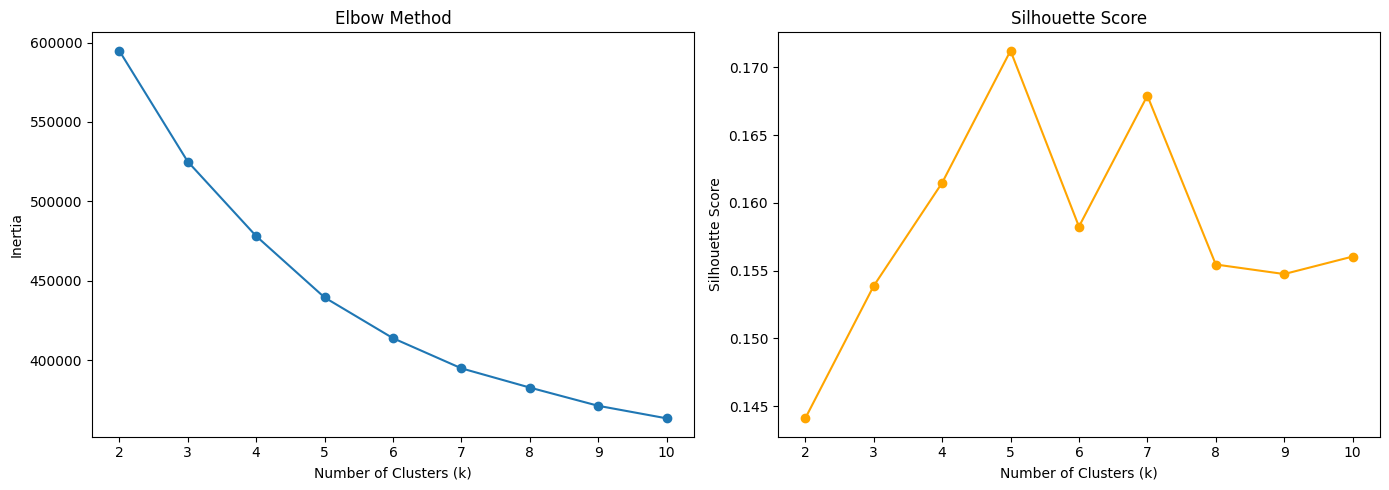

In [4]:
inertias, silhouette_scores = find_optimal_k(df_processed_st)

### K-Means

In [5]:
"""# Determine best k from previous search if available, otherwise default to 5
try:
    ks = list(range(2, 2 + len(silhouette_scores)))
    best_k = ks[int(np.argmax(silhouette_scores))]
except Exception:
    best_k = 5

print(f"Selected k: {best_k}")"""

'# Determine best k from previous search if available, otherwise default to 5\ntry:\n    ks = list(range(2, 2 + len(silhouette_scores)))\n    best_k = ks[int(np.argmax(silhouette_scores))]\nexcept Exception:\n    best_k = 5\n\nprint(f"Selected k: {best_k}")'

In [6]:
print(fit_kmeans(df_processed_st, 5))


Silhouette Score: 0.1712
Cluster sizes:
0     3002
1     7050
2     8849
3     3786
4    10351
Name: count, dtype: int64
                                         cluster_0  cluster_1  cluster_2  \
kids_home                                 2.099707  -0.067346  -0.076590   
teens_home                                2.028047  -0.016503  -0.347230   
number_complaints                         0.026084  -0.266309   0.291643   
distinct_stores_visited                   0.033319   0.127301   0.186740   
lifetime_spend_groceries                  0.725751  -0.348640  -0.436496   
lifetime_spend_electronics                0.938434  -0.214523  -0.752633   
typical_hour                             -0.512938  -0.040429  -0.010192   
lifetime_spend_vegetables                 0.151290   1.586355  -0.503796   
lifetime_spend_nonalcohol_drinks          0.988752   0.333365  -1.043077   
lifetime_spend_alcohol_drinks             1.153433  -0.582674  -0.323830   
lifetime_spend_meat                       0

# Hierarchical Clustering

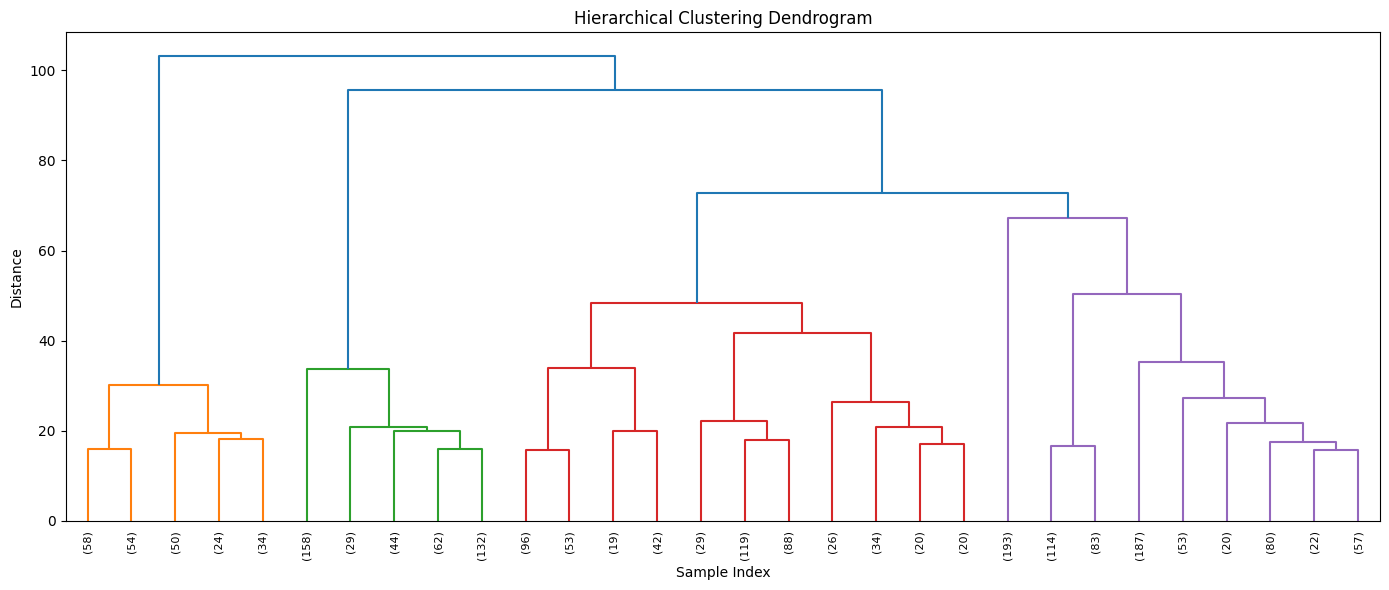

Silhouette Score: 0.1548
Cluster sizes:
0    11208
1     7642
2     6867
3     3456
4     3865
Name: count, dtype: int64
(AgglomerativeClustering(n_clusters=5), array([0, 2, 1, ..., 2, 0, 0], shape=(33038,)))


In [7]:
print(fit_hierarchical(df_processed_st, 5, method='ward'))

# DBSCAN 

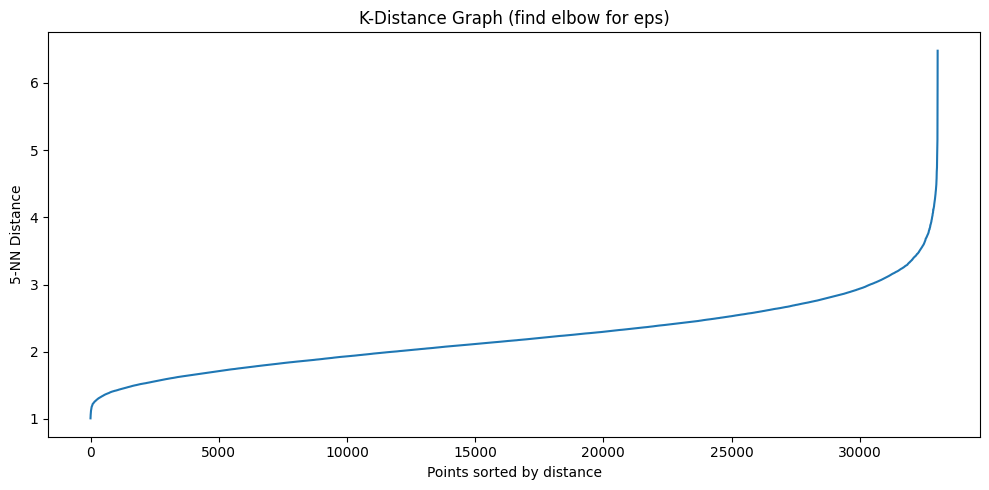

None


In [8]:
print(find_optimal_eps(df_processed_st, n_neighbors=5))

In [9]:
print(fit_dbscan(df_processed_st, 2.5, min_samples=5)) 

Number of clusters: 6
Noise points: 5079 (15.37%)
Silhouette Score (excluding noise): -0.0918
Cluster sizes:
-1     5079
 0    27941
 1        2
 2        3
 3        5
 4        3
 5        5
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([-1,  0, -1, ...,  0, -1,  0], shape=(33038,)))


In [10]:
print(fit_dbscan(df_processed_st, 3, min_samples=5)) 

Number of clusters: 2
Noise points: 1199 (3.63%)
Silhouette Score (excluding noise): 0.2195
Cluster sizes:
-1     1199
 0    31832
 1        7
Name: count, dtype: int64
(DBSCAN(eps=3), array([ 0,  0, -1, ...,  0,  0,  0], shape=(33038,)))


In [11]:
print(fit_dbscan(df_processed_st, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 302 (0.91%)
Cluster sizes:
-1      302
 0    32736
Name: count, dtype: int64
(DBSCAN(eps=3.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


# Self-Organizing Map (SOM)

In [12]:
# Weights initialization  
initial_weights = _initialize_som_weights(df_processed_st, map_shape=(30, 30), random_state=42)

# 2. Find the BMU for all customers
all_bmus = [_find_bmu(initial_weights, row) for row in df_processed_st.values]

# 3. Print the coordinates for the first 5 customers to check the result
print(all_bmus[:5])

[(np.int64(12), np.int64(18)), (np.int64(12), np.int64(18)), (np.int64(0), np.int64(5)), (np.int64(12), np.int64(18)), (np.int64(0), np.int64(27))]


In [13]:
print(_som_learning_rate(initial_lr = 0.1, iteration = 100, n_iterations = 1000))

0.09048374180359596


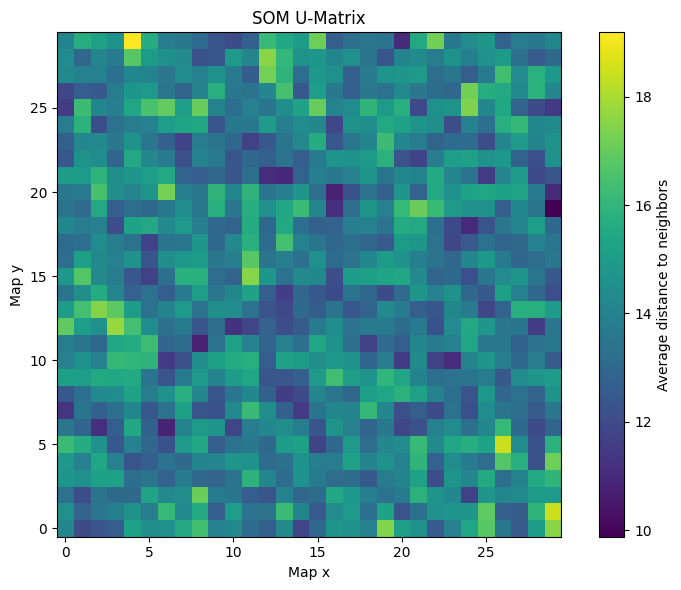

[[14.18807935 12.05831207 12.32859521 12.6692735  15.19391695 14.51056606
  14.53796749 15.49838988 16.38154385 13.95327987 14.27682346 13.15985522
  12.72186444 14.26048313 11.8368521  12.96052955 14.73658062 14.64746901
  13.97792381 17.44514542 15.17877197 14.63585894 12.53913721 13.92745018
  15.39058923 16.78610312 13.6195293  12.55549329 15.03425182 17.53524022]
 [14.55427517 12.8478758  13.53718846 13.90449478 14.61053833 13.80801123
  16.12318921 14.34520352 15.53752836 12.67294016 15.10188923 13.41164984
  13.45466103 16.24108113 14.08375817 12.5497789  14.38394208 14.86158283
  13.27376583 15.22455778 12.33849663 13.33156279 14.61001889 14.72740906
  14.77875509 16.87196269 12.67735252 12.61111349 15.98429538 18.43061983]
 [13.35591469 12.11980893 13.4423192  13.09134495 13.10519096 15.31705493
  14.26078887 14.47701793 17.09557417 13.71595073 13.48339963 12.66460488
  12.34302529 14.01317678 12.957127   13.15788244 15.4745809  14.85806574
  13.88097475 13.38863242 13.7499165

In [14]:
print(plot_som_u_matrix(initial_weights))

In [15]:
print(fit_som(df_processed_st, map_shape=(10, 10), num_iterations=1000, initial_learning_rate=0.1, initial_radius=5.0, random_state=42))

TypeError: fit_som() got an unexpected keyword argument 'num_iterations'

In [ ]:
print(get_som_cluster_labels(initial_weights, df_processed_st))

InvalidParameterError: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got        kids_home  teens_home  number_complaints  distinct_stores_visited  \
0      -0.101289    0.104973           0.077284                -0.100222   
1      -0.101289   -0.936120          -1.047915                -0.699459   
2      -0.972747   -0.936120          -0.372796                -0.699459   
3      -0.972747   -0.936120           1.202483                -1.298695   
4      -0.972747   -0.936120           2.327682                -1.298695   
...          ...         ...                ...                      ...   
33033  -0.972747   -0.936120           1.202483                -1.298695   
33034  -0.101289   -0.936120           0.077284                -1.298695   
33035  -0.101289    0.104973          -1.047915                 0.499014   
33036  -0.101289    0.104973           0.077284                 1.697487   
33037  -0.972747    0.104973           0.077284               

In [ ]:
print(assign_som_clusters(initial_weights, df_processed_st,n_clusters=5))

(array([2, 2, 2, ..., 2, 1, 2], shape=(33038,), dtype=int32), array([[0, 4, 0, 0, 4, 2, 4, 2, 0, 1, 1, 2, 3, 3, 1, 1, 4, 0, 2, 4, 3, 1,
        3, 4, 3, 4, 3, 2, 4, 3],
       [4, 0, 3, 2, 3, 0, 1, 3, 2, 2, 0, 2, 0, 4, 2, 0, 0, 3, 2, 2, 4, 0,
        0, 2, 4, 3, 3, 2, 3, 0],
       [3, 1, 2, 2, 0, 4, 1, 1, 0, 3, 2, 1, 0, 2, 1, 3, 3, 2, 3, 0, 4, 2,
        4, 2, 4, 4, 4, 3, 2, 2],
       [0, 4, 3, 0, 2, 2, 3, 3, 3, 0, 3, 0, 4, 0, 4, 4, 4, 2, 1, 0, 4, 3,
        1, 3, 4, 2, 2, 2, 4, 1],
       [2, 0, 0, 4, 2, 4, 2, 2, 1, 4, 4, 2, 2, 0, 0, 0, 0, 0, 4, 2, 4, 2,
        4, 4, 3, 4, 4, 3, 3, 0],
       [4, 4, 1, 4, 4, 4, 3, 0, 3, 4, 0, 2, 1, 3, 0, 2, 3, 2, 2, 1, 4, 3,
        4, 0, 1, 4, 2, 2, 3, 0],
       [0, 4, 0, 3, 3, 0, 3, 3, 2, 0, 0, 2, 4, 2, 4, 3, 1, 0, 2, 2, 2, 3,
        3, 2, 3, 1, 4, 4, 1, 1],
       [0, 3, 4, 4, 2, 4, 0, 4, 2, 3, 0, 2, 3, 0, 4, 0, 4, 0, 0, 2, 0, 3,
        0, 3, 2, 4, 0, 0, 1, 3],
       [0, 1, 2, 4, 3, 0, 2, 1, 3, 3, 3, 1, 2, 2, 1, 1, 0, 4, 1, 3, 0, 1,
        

# Compare all models 

In [ ]:
labels_dict = {
    'KMeans': fit_kmeans(df_processed_st, 5),
    'Hierarchical': fit_hierarchical(df_processed_st, 5, method='ward'),
    'DBSCAN_3': fit_dbscan(df_processed_st, 3, min_samples=5),
    'SOM': fit_som(df_processed_st, map_shape=(10, 10), num_iterations=1000, initial_learning_rate=0.1, initial_radius=5.0, random_state=42)
}
print(compare_models(df_processed_st, labels_dict))


NameError: name 'fit_kmeans' is not defined